In [9]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Định nghĩa cùng một bảng màu để đảm bảo tính nhất quán
COLOR_MAP = {
    "Tay ga": "#3498db",
    "Xe số": "#2ecc71",
    "Xe thể thao": "#e74c3c",
    "Xe 50cc": "#f1c40f",
    "Khác": "#95a5a6"
}

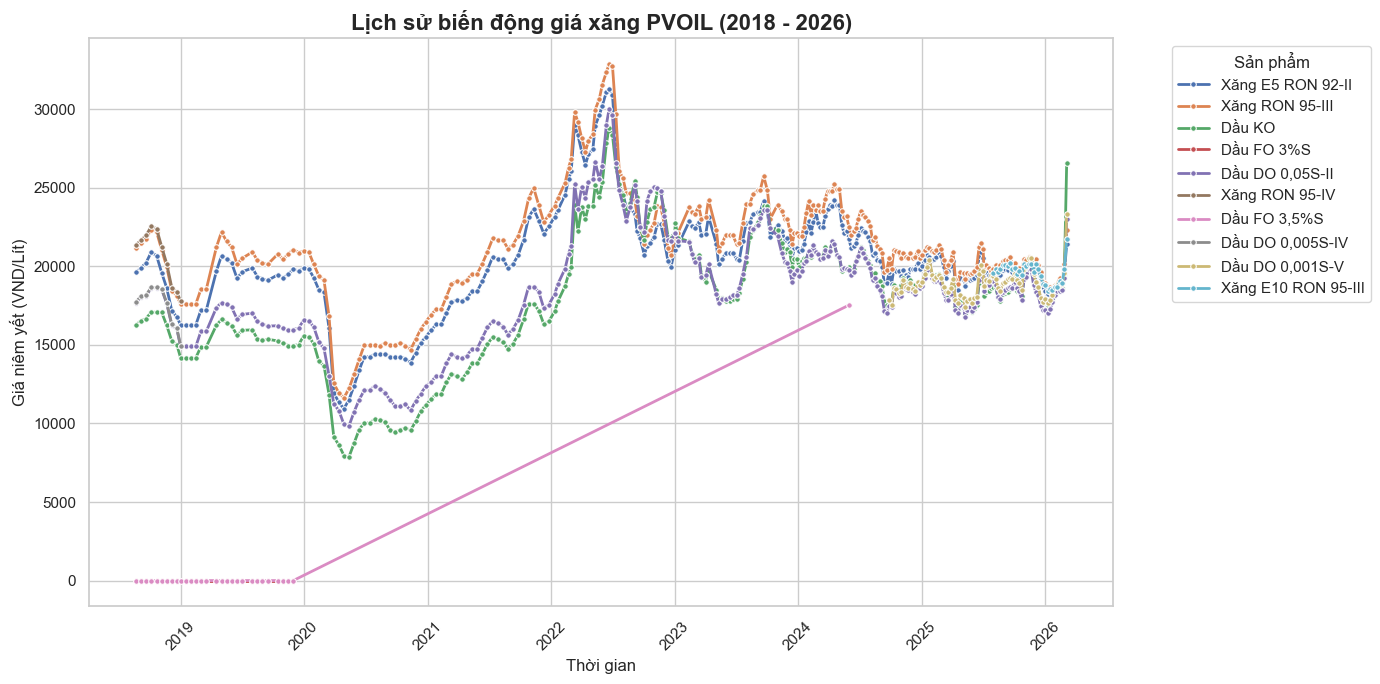

In [10]:

def report_fuel_price_trends(json_path="pvoil_prices.json"):
    # 1. Đọc dữ liệu JSON
    if not os.path.exists(json_path):
        print(f"Không tìm thấy file {json_path}")
        return
        
    with open(json_path, 'r', encoding='utf-8') as f:
        price_data = json.load(f)

    # 2. Chuyển đổi JSON sang DataFrame
    price_records = []
    for date_str, info in price_data.items():
        # Lấy danh sách xăng trong ngày đó
        fuels = info.get('fuels', [])
        for item in fuels:
            price_records.append({
                "Ngày": date_str,
                "Loại xăng": item['fuel_type'],
                "Giá (VND)": item['price_vnd']
            })

    df = pd.DataFrame(price_records)
    
    # Chuyển cột Ngày sang định dạng datetime và sắp xếp
    df['Ngày'] = pd.to_datetime(df['Ngày'], format='%d-%m-%Y')
    df = df.sort_values('Ngày')

    # 3. Vẽ biểu đồ
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 7))

    # Vẽ đường line cho từng loại xăng
    sns.lineplot(data=df, x='Ngày', y='Giá (VND)', hue='Loại xăng', linewidth=2, marker='o', markersize=4)

    # Định dạng biểu đồ
    plt.title("Lịch sử biến động giá xăng PVOIL (2018 - 2026)", fontsize=16, fontweight='bold')
    plt.xlabel("Thời gian", fontsize=12)
    plt.ylabel("Giá niêm yết (VND/Lít)", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title="Sản phẩm", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    report_fuel_price_trends()

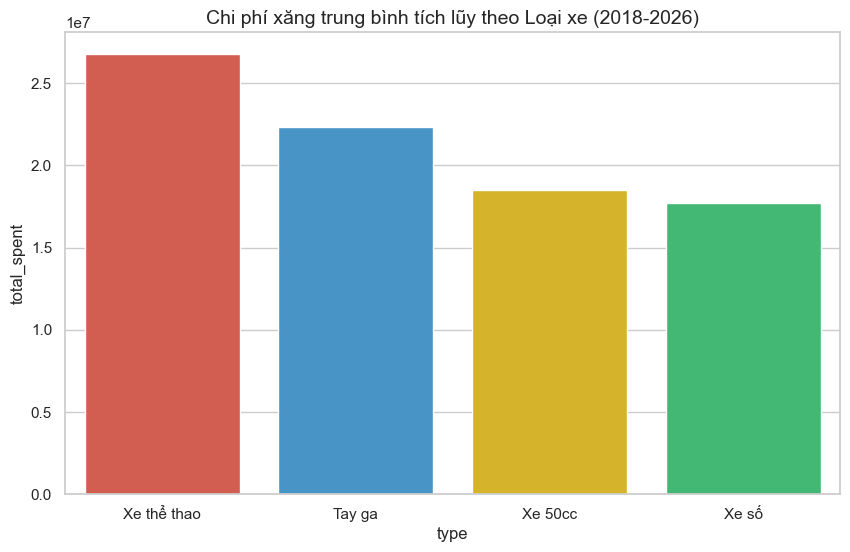

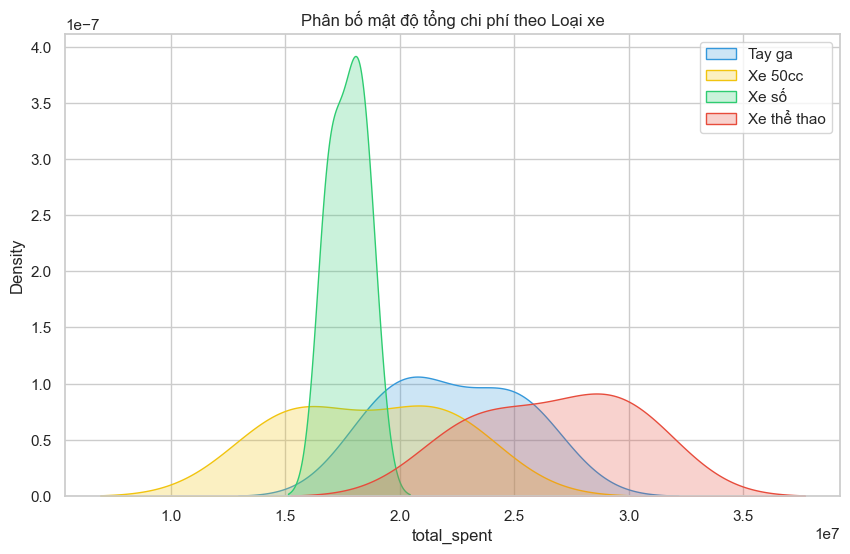

In [11]:
def visualize_by_vehicle_type(json_path="01.fuel_purchase_history.json", csv_path="bike_fuel_rate.csv"):
    if not os.path.exists(csv_path):
        print(f"Không tìm thấy file tại {csv_path}")
        return
        
    bikes_df = pd.read_csv(csv_path)
    bikes_df.columns = bikes_df.columns.str.strip()
    
    if 'Loại xe' not in bikes_df.columns:
        print(f"Lỗi: Không tìm thấy cột 'Loại xe'.")
        return

    bikes_df['full_name'] = (bikes_df['Hãng xe'].str.strip() + " " + bikes_df['Dòng xe'].str.strip())
    type_map = dict(zip(bikes_df['full_name'], bikes_df['Loại xe'].str.strip()))

    with open(json_path, 'r', encoding='utf-8') as f:
        sim_data = json.load(f)
    
    all_records = []
    summary_list = []
    
    for bike_name, info in sim_data.items():
        v_type = type_map.get(bike_name.strip(), "Khác")
        summary_list.append({
            "bike_name": bike_name.strip(),
            "total_spent": info['total_spent'],
            "type": v_type,
            "avg_bill": info['total_spent'] / info['total_purchases'] if info['total_purchases'] > 0 else 0
        })
        for record in info['history']:
            record['type'] = v_type
            all_records.append(record)
    
    df = pd.DataFrame(all_records)
    summary_df = pd.DataFrame(summary_list)

    sns.set_theme(style="whitegrid")
    
    # --- CHART 1: TỔNG CHI PHÍ TRUNG BÌNH ---
    plt.figure(figsize=(10, 6))
    avg_by_type = summary_df.groupby('type')['total_spent'].mean().sort_values(ascending=False).reset_index()
    # Sử dụng palette=COLOR_MAP để đồng bộ màu
    sns.barplot(data=avg_by_type, x='type', y='total_spent', hue='type', palette=COLOR_MAP, legend=False)
    plt.title("Chi phí xăng trung bình tích lũy theo Loại xe (2018-2026)", fontsize=14)
    plt.show()

    # --- CHART 2: DENSITY PLOT ---
    plt.figure(figsize=(10, 6))
    for v_type in sorted(summary_df['type'].unique()):
        sns.kdeplot(
            summary_df[summary_df['type'] == v_type]['total_spent'], 
            label=v_type, 
            fill=True, 
            color=COLOR_MAP.get(v_type, "#95a5a6") # Lấy màu từ COLOR_MAP
        )
    plt.title("Phân bố mật độ tổng chi phí theo Loại xe")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    visualize_by_vehicle_type()

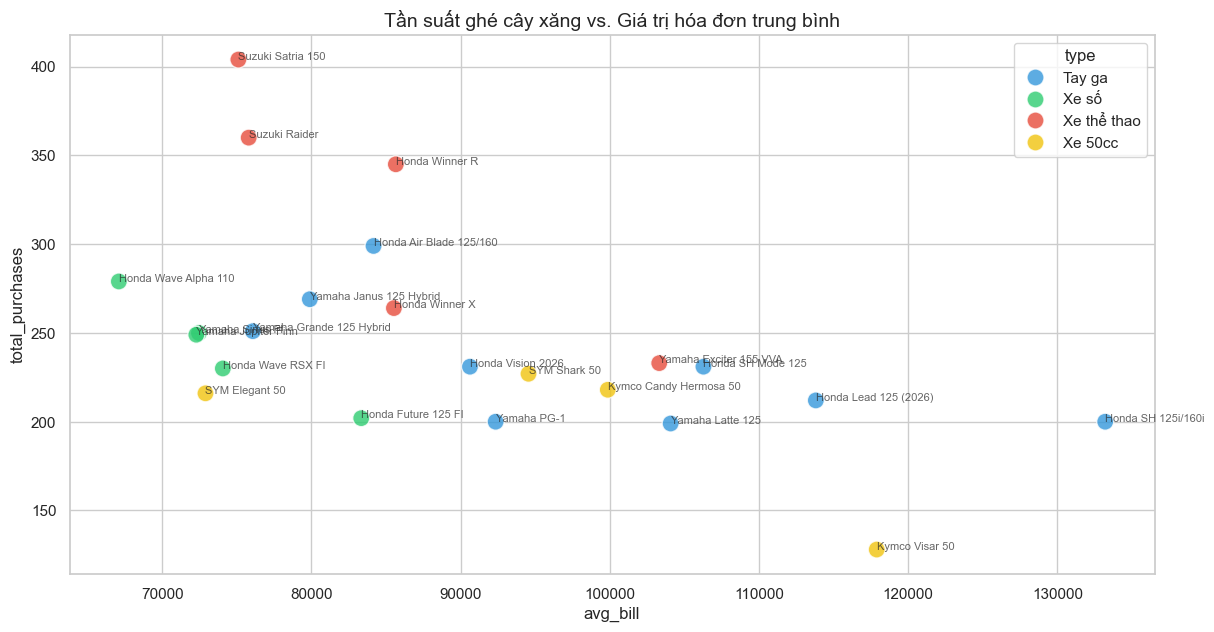

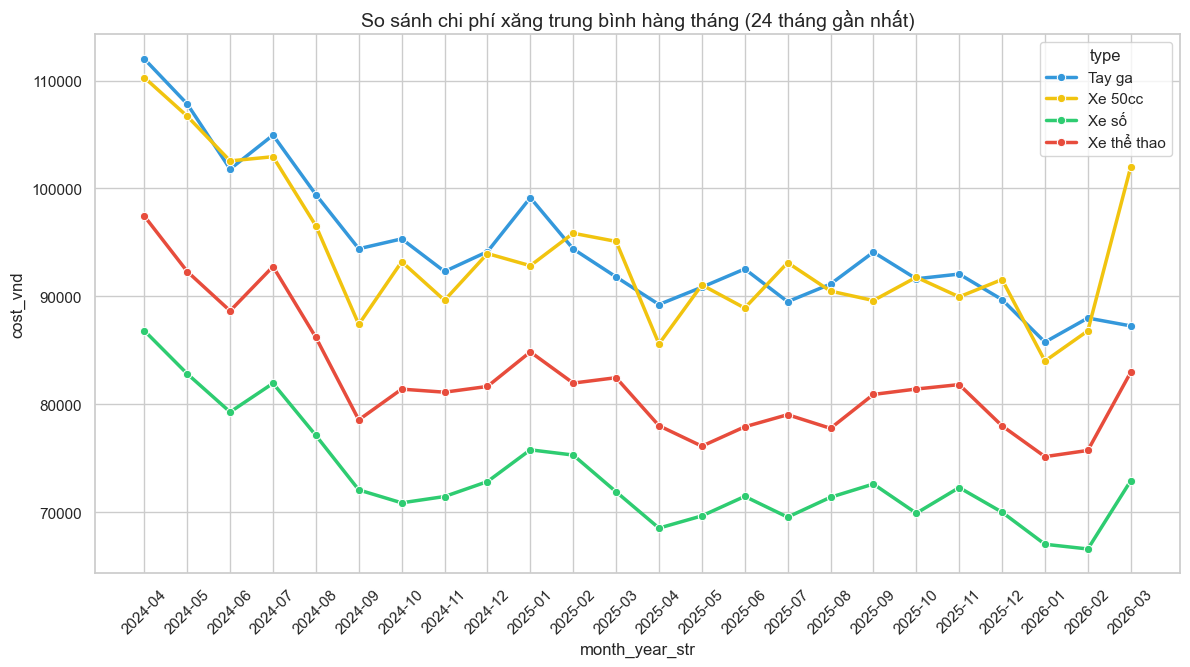

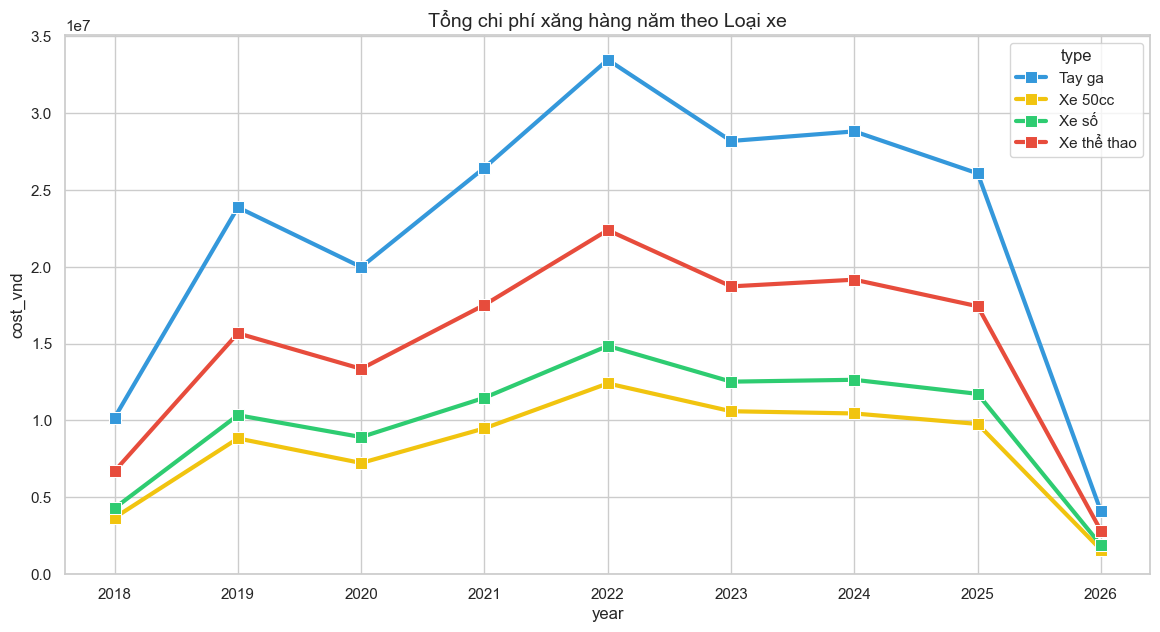

In [14]:
def visualize_comparison(json_path="01.fuel_purchase_history.json", csv_path="bike_fuel_rate.csv"):
    if not os.path.exists(csv_path):
        print("Không tìm thấy file CSV.")
        return
    
    bikes_df = pd.read_csv(csv_path)
    bikes_df.columns = bikes_df.columns.str.strip()
    bikes_df['full_name'] = (bikes_df['Hãng xe'].str.strip() + " " + bikes_df['Dòng xe'].str.strip())
    type_map = dict(zip(bikes_df['full_name'], bikes_df['Loại xe'].str.strip()))

    with open(json_path, 'r', encoding='utf-8') as f:
        sim_data = json.load(f)
    
    history_records = []
    summary_records = []

    for bike_name, info in sim_data.items():
        v_type = type_map.get(bike_name, "Khác")
        summary_records.append({
            "bike_name": bike_name,
            "total_spent": info['total_spent'],
            "total_purchases": info['total_purchases'],
            "avg_bill": info['total_spent'] / info['total_purchases'] if info['total_purchases'] > 0 else 0,
            "type": v_type
        })
        for record in info['history']:
            history_records.append({
                "date": record['date'],
                "cost_vnd": record['cost_vnd'],
                "type": v_type
            })

    df = pd.DataFrame(history_records)
    summary_df = pd.DataFrame(summary_records)
    df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
    df['month_year'] = df['date'].dt.to_period('M')
    df['year'] = df['date'].dt.year

    sns.set_theme(style="whitegrid")

    # --- BIỂU ĐỒ 1: TẦN SUẤT vs GIÁ TRỊ BILL (SCATTER) ---
    plt.figure(figsize=(14, 7))
    sns.scatterplot(data=summary_df, x='avg_bill', y='total_purchases', hue='type', 
                    palette=COLOR_MAP, s=150, alpha=0.8)
    for i, row in summary_df.iterrows():
        plt.text(row['avg_bill'], row['total_purchases'], row['bike_name'], fontsize=8, alpha=0.7)
    plt.title("Tần suất ghé cây xăng vs. Giá trị hóa đơn trung bình", fontsize=14)
    plt.show()

    # --- BIỂU ĐỒ 2: BILL MỖI THÁNG - LINE CHART ---
    monthly_type_df = df.groupby(['type', 'month_year'])['cost_vnd'].mean().reset_index()
    monthly_type_df['month_year_str'] = monthly_type_df['month_year'].astype(str)
    
    plt.figure(figsize=(14, 7))
    recent_months = sorted(monthly_type_df['month_year_str'].unique())[-24:]
    plot_df = monthly_type_df[monthly_type_df['month_year_str'].isin(recent_months)]
    
    # Dùng palette=COLOR_MAP để các đường line có màu đồng bộ
    sns.lineplot(data=plot_df, x='month_year_str', y='cost_vnd', hue='type', 
                 palette=COLOR_MAP, marker='o', linewidth=2.5)
    plt.title("So sánh chi phí xăng trung bình hàng tháng (24 tháng gần nhất)", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

    # --- BIỂU ĐỒ 3: BILL MỖI NĂM - LINE CHART ---
    yearly_type_df = df.groupby(['type', 'year'])['cost_vnd'].sum().reset_index()
    
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=yearly_type_df, x='year', y='cost_vnd', hue='type', 
                 palette=COLOR_MAP, marker='s', markersize=8, linewidth=3)
    plt.title("Tổng chi phí xăng hàng năm theo Loại xe", fontsize=14)
    plt.show()

if __name__ == "__main__":
    visualize_comparison()

Dưới đây là bảng tổng hợp ngắn gọn các đặc điểm tiêu thụ xăng dựa trên kết quả mô phỏng:

### **Phân tích đặc điểm tiêu thụ theo Loại xe**

| Loại xe | Đặc điểm Bình & Máy | Hóa đơn (Bill size) | Tần suất đổ xăng | Chi phí năm |
| --- | --- | --- | --- | --- |
| **Tay ga** | Bình lớn | **Cao nhất** | Trung bình |  **Cao nhất** |
| **Xe 50cc** | Bình lớn + Máy cực tiết kiệm | **Cao** | **Thấp nhất** | **Thấp nhất** |
| **Xe số** | Bình nhỏ + Máy tiết kiệm | Thấp | Thấp | Thấp |
| **Xe thể thao** | Bình nhỏ + Máy ngốn xăng | Thấp | **Cao nhất** | Cao |

---

### **Kết luận chính**

* **"Đau ví" mỗi lần đổ:** Gọi tên **Tay ga** và **Xe 50cc** (do dung tích bình xăng lớn).
* **"Phiền phức" nhất:** Thuộc về **Xe thể thao** (Sportbikes) — bạn sẽ thấy mình "định cư" ở trạm xăng vì bình quá nhỏ so với công suất máy.
* **Kinh tế tổng thể:** **Xe số** và **Xe 50cc** là "vua" tiết kiệm, mang lại hóa đơn tổng cả năm (Yearly Bill) dễ thở nhất.